# Gaussian Splatting

## Overview COLMAP
Gaussian Splatting (GS) represents a scene as a set of 3D gaussians, which are
optimized by rendering them from the viewpoint of each input image and comparing
the result with that "ground truth" image. Once optimized, the Gaussians can be
rendered from any new viewpoint in real time, which is called novel view
synthesis. To optimize them (i.e. to move the gaussians to the right locations
with the right colors), we need the camera pose and camera parameters of every
input image. 

<img src="images/tomato_scene_to_gaussian_splats.png" style="width: 2000px;">

We estimate these with COLMAP, a Structure-from-Motion (SfM) and Multi-View
Stereo (MVS) pipeline that works on overlapping images, i.e. multiple images of
the same subject taken from different angles. GS only needs the SfM stage. The
COLMAP stages:

```text
Images
  ↓
Feature extraction
  ↓
Feature matching
  ↓
SfM (Structure-from-Motion)
  ├─ Camera intrinsics
  ├─ Camera poses
  ├─ Sparse 3D points
  └─ Bundle adjustment
  ↓
MVS (Multi-View Stereo)
  ├─ Depth maps
  ├─ Dense point cloud
  └─ Mesh
  ```

## Running COLMAP

Install COLMAP on Ubuntu with:

```bash
sudo apt update
sudo apt install colmap
```

Run the reconstruction with `colmap_commands.sh`. Set `IMAGES` in the script to
the directory containing the input images. During feature extraction, the script
uses:

```bash
--SiftExtraction.max_image_size 5000
```

This limits the largest image dimension used for SIFT feature extraction to 5000
pixels. Making it smaller speeds up extraction, but may reduce feature-matching
accuracy.

The mapper writes one folder per reconstruction:

```text
colmap_results/
├── 0/
├── 1/
└── ...
```

Normally, there is only `0/`. Additional folders mean that COLMAP split the
reconstruction into disconnected components. Each reconstruction contains the
same three files:

```text
cameras.bin
images.bin
points3D.bin
```

Only **registered** images appear in the reconstruction files. Images that
COLMAP could not localize are simply absent.

### Image undistortion

After reconstruction, the script runs `image_undistorter` on every
reconstruction. This removes lens distortion from the input images and converts
the camera model to a pinhole representation suitable for 3D Gaussian Splatting.

```text
colmap_results/
├── 0/
└── 0_undistorted/
    ├── images/
    ├── sparse/
    └── sparse_txt/
```

The `stereo/` directory and COLMAP helper scripts are removed because they are
only needed for dense MVS reconstruction, which is not used here. The
undistorted sparse model is also converted from `.bin` to `.txt` in
`sparse_txt/` for easier inspection; both formats contain the same
reconstruction data.

In [1]:
import numpy as np
import plotly.graph_objects as go

from utils.colmap import read_images_txt, read_points3D_txt



In [2]:
# Visualize COLMAP results
MODEL = "colmap_results/0_undistorted/sparse_txt"

# 1. cameras.txt stores one camera's intrinsics per line: CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[].
# For the PINHOLE model, PARAMS[] = fx, fy, cx, cy: focal lengths and principal point in pixels.
### No visualization ###


# 2. images.txt stores each image over two lines:
#    IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME
#    POINTS2D[] as (X, Y, POINT3D_ID)
# (q, t) map world to camera: x_cam = R @ x_world + t, so the camera center is C = -R^T t.
# POINT3D_ID = -1 means the keypoint was not triangulated into a 3D point.
images = read_images_txt(f"{MODEL}/images.txt")
print(f"{len(images)} images")


# 3. points3D.txt stores one triangulated point per line:
#    POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[] as (IMAGE_ID, POINT2D_IDX)
# ERROR is the mean reprojection error in pixels.
# TRACK lists every image that observes the point, with the keypoint's index in that image's POINTS2D.
points = read_points3D_txt(f"{MODEL}/points3D.txt")
print(f"{len(points.ids)} points")

166 images
25925 points


In [3]:
images

{127: Image(id=127, qvec=array([ 0.55296349, -0.05975319,  0.45148686,  0.69772527]), tvec=array([ 0.81476471, -1.12802645,  0.72183364]), camera_id=127, name='00126.jpg', xys=array([[2831.70115278,  696.57978953],
        [2851.78884783,  720.346716  ],
        [2855.75116136,  759.78522766],
        ...,
        [6776.48207804, 3201.05458236],
        [3325.17899542, 2387.27965423],
        [6279.27268548, 4198.96578849]], shape=(2181, 2)), point3D_ids=array([-1, -1, -1, ..., -1, -1, -1], shape=(2181,))),
 126: Image(id=126, qvec=array([ 0.53193907, -0.01708803,  0.45807572,  0.71197996]), tvec=array([ 0.71108084, -1.11879535,  1.32882329]), camera_id=126, name='00125.jpg', xys=array([[4759.78566405,  872.28582951],
        [4759.78566405,  872.28582951],
        [3162.14438538, 1150.61800449],
        ...,
        [3889.88043767, 3131.35263324],
        [6583.9528014 , 4136.53413887],
        [6583.9528014 , 4136.53413887]], shape=(3584, 2)), point3D_ids=array([   -1,    -1,    -1, 

In [6]:
points

Points3D(ids=array([15053, 15052, 15051, ...,   578,   579,   580], shape=(25925,)), xyz=array([[ 0.93211999,  1.48565673,  1.39812809],
       [ 0.64141741,  0.69773421,  1.90007163],
       [ 0.70184009,  0.74196547,  1.87159282],
       ...,
       [-1.02491195,  1.80414719,  1.23960085],
       [-0.89922323,  1.76014733,  1.26703438],
       [-0.85220037,  1.74833424,  1.27001997]], shape=(25925, 3)), rgb=array([[ 39,  60,  59],
       [ 64,  83,  83],
       [ 88, 104, 104],
       ...,
       [ 73, 147, 124],
       [ 47,  72,  69],
       [101, 113, 113]], shape=(25925, 3), dtype=uint8), errors=array([0.5348696 , 0.75637152, 0.39516267, ..., 0.81481802, 0.31105701,
       1.94728456], shape=(25925,)), tracks=[array([[  71, 1395],
       [  70,  572],
       [ 126, 2395]]), array([[  87, 4194],
       [ 125, 3068],
       [  70,  482]]), array([[  87, 4185],
       [ 125, 3066],
       [  70,  470]]), array([[  87, 2154],
       [  89, 3541],
       [  70,  452],
       [ 126, 25

## 1. Visualize Poses of Cameras (from COLMAP)

In [4]:
import numpy as np
import plotly.graph_objects as go

MODEL = "colmap_results/0_undistorted/sparse_txt"


def quat_to_rot(qw, qx, qy, qz):
    return np.array([
        [1 - 2 * (qy**2 + qz**2), 2 * (qx * qy - qz * qw), 2 * (qx * qz + qy * qw)],
        [2 * (qx * qy + qz * qw), 1 - 2 * (qx**2 + qz**2), 2 * (qy * qz - qx * qw)],
        [2 * (qx * qz - qy * qw), 2 * (qy * qz + qx * qw), 1 - 2 * (qx**2 + qy**2)],
    ])


# images.txt: two lines per image; the pose is on the first.
with open(f"{MODEL}/images.txt") as f:
    lines = [l for l in f.read().splitlines() if not l.startswith("#")]

names, centers, dirs, ups = [], [], [], []
for line in lines[0::2]:
    v = line.split()
    R = quat_to_rot(*map(float, v[1:5]))      # world-to-camera rotation
    t = np.array(list(map(float, v[5:8])))
    centers.append(-R.T @ t)                   # camera center in world
    dirs.append(R.T @ [0, 0, 1])               # viewing direction in world
    ups.append(R.T @ [0, -1, 0])               # camera up (-y) in world
    names.append(v[9])
centers, dirs = np.array(centers), np.array(dirs)

# points3D.txt: X Y Z R G B ERROR, then (IMAGE_ID POINT2D_IDX) pairs.
with open(f"{MODEL}/points3D.txt") as f:
    rows = [l.split() for l in f if not l.startswith("#")]
pts = np.array([r[1:8] for r in rows], dtype=float)
track_len = np.array([(len(r) - 8) // 2 for r in rows])

center = centers.mean(axis=0)
radius = np.linalg.norm(centers - center, axis=1).max()
keep = (
    (pts[:, 6] < 1.0)                                          # low reprojection error
    & (track_len >= 3)                                         # seen in at least 3 images
    & (np.linalg.norm(pts[:, :3] - center, axis=1) < radius)   # inside the camera dome
)
pts = pts[keep]
pts = pts[np.random.choice(len(pts), min(len(pts), 20000), replace=False)]

# One line segment per camera, separated by None so they're not connected.
scale = 0.1 * np.ptp(centers, axis=0).max()
tips = centers + scale * dirs
seg = np.full((len(centers) * 3, 3), None)
seg[0::3], seg[1::3] = centers, tips

# Scene up: average of the cameras' up directions.
up = np.mean(ups, axis=0)
up /= np.linalg.norm(up)

fig = go.Figure([
    go.Scatter3d(x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="markers",
                 marker=dict(size=1, color=[f"rgb({r:.0f},{g:.0f},{b:.0f})" for r, g, b in pts[:, 3:6]]),
                 name="points", hoverinfo="skip"),
    go.Scatter3d(x=centers[:, 0], y=centers[:, 1], z=centers[:, 2], mode="markers",
                 marker=dict(size=3, color="red"), text=names, name="cameras"),
    go.Scatter3d(x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode="lines",
                 line=dict(color="red"), name="view directions", hoverinfo="skip"),
])
fig.update_layout(
    scene=dict(aspectmode="data"),
    scene_camera=dict(up=dict(x=up[0], y=up[1], z=up[2])),
    height=800,
)
fig.show()

## 2. Gaussian Splatting with [gsplat](https://docs.gsplat.studio/main/) library

In [5]:
%%bash

# Using simple_trainer.
cd ~/Apps/gsplat/examples

python simple_trainer.py default \
    --data_dir ~/code/MA/gs-intro/colmap_results/0_undistorted \
    --data_factor 8 \
    --packed \
    --save_ply \
    --result_dir ~/code/MA/gs-intro/gsplat_results/tomatoes \
    --max_steps 5000 --eval_steps 2500 5000 --save_steps 2500 5000

[Parser] 166 images, taken by 166 cameras.
Downscaling images by 8x from /home/boldi/code/MA/gs-intro/colmap_results/0_undistorted/images to /home/boldi/code/MA/gs-intro/colmap_results/0_undistorted/images_8_png.


Loading EXIF exposure: 100%|██████████| 166/166 [00:00<00:00, 3998.27it/s]


[Parser] No valid EXIF exposure data found in any image.
Scene scale: 1.529745695083774
Model initialized. Number of GS: 25925
╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯


loss=0.113| sh degree=0| :  12%|█▏        | 594/5000 [00:10<01:13, 59.97it/s]

Step 600: 1334 GSs duplicated, 776 GSs split. Now having 28035 GSs.
Step 600: 22 GSs pruned. Now having 28013 GSs.


...

Step 700: 2467 GSs duplicated, 1256 GSs split. Now having 31736 GSs.
Step 700: 33 GSs pruned. Now having 31703 GSs.


loss=0.102| sh degree=0| :  15%|█▍        | 733/5000 [00:12<01:16, 55.69it/s]Exception in thread Thread-3 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/boldi/miniconda3/envs/ma/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
loss=0.102| sh degree=0| :  15%|█▍        | 734/5000 [00:12<01:12, 59.08it/s]
Traceback (most recent call last):
  File "/home/boldi/Apps/gsplat/examples/simple_trainer.py", line 1617, in <module>
    self.run()
  File "/home/boldi/miniconda3/envs/ma/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/home/boldi/miniconda3/envs/ma/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    cli(main, cfg, verbose=True)
  File "/home/boldi/Apps/gsplat/gsplat/distributed.py", line 375, in cli
    do_one_step()
  File "/home/boldi/miniconda3/envs/ma/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
 

(viser) Server stopped


TypeError: %d format: a real number is required, not NoneType

TypeError: %d format: a real number is required, not NoneType

In [ ]:
%%bash

# Using simple_trainer mcmc.
cd ~/Apps/gsplat/examples

python simple_trainer.py mcmc \
    --data_dir ~/code/MA/gs-intro/colmap_results/0_undistorted \
    --data_factor 8 \
    --packed \
    --save_ply \
    --strategy.cap-max 300000 \
    --result_dir ~/code/MA/gs-intro/gsplat_results/tomatoes_mcmc \
    --max_steps 5000 --eval_steps 2500 5000 --save_steps 2500 5000

## gsplat Training Output

Each run writes one result folder, e.g. `gsplat_results/tomatoes/`:

| Folder | Content |
| --- | --- |
| `ckpts/` | `ckpt_<step>_rank0.pt`: the trained model, a PyTorch dict with every Gaussian parameter (means, quats, scales, opacities, SH coefficients) plus the step and config |
| `ply/` | `point_cloud_<step>.ply`: the same Gaussians in the standard 3DGS PLY format, written only with `--save_ply` |
| `renders/` | `val_step<step>_XXXX.png`: held-out views, ground truth and render side by side |
| `videos/` | `traj_<step>.mp4`: a fly-through along an interpolated camera path |
| `stats/` | `val_step<step>.json` with PSNR, SSIM, LPIPS and the Gaussian count; `train_step*.json` with timing and memory |
| `tb/` + `cfg.yml` | TensorBoard logs and the exact config the run used |

### Inspect the model interactively

```bash
cd ~/Apps/gsplat/examples
python simple_viewer.py \
    --ckpt ~/code/MA/gs-intro/gsplat_results/tomatoes/ckpts/ckpt_4999_rank0.pt \
    --port 8080
```

### Open the PLY in other tools

The PLY is the portable format. It loads in PlayCanvas's SuperSplat editor (browser-based, also crops and cleans), the Unity and Unreal plugins, Blender add-ons and web viewers. This is the file to share or embed, not the checkpoint.

### Load the parameters directly

```python
import torch

ckpt = torch.load("ckpts/ckpt_4999_rank0.pt", map_location="cpu")
splats = ckpt["splats"]
print({k: tuple(v.shape) for k, v in splats.items()})
```

The tensors can be rendered into new views with `gsplat.rasterization()`, or compared against another trainer's output.

### Read the baseline numbers

```bash
cat gsplat_results/tomatoes/stats/val_step4999.json
tensorboard --logdir gsplat_results/tomatoes/tb
```

`val_step*.json` is the reference any other trainer has to be measured against, at the same resolution and the same held-out split (every 8th image, `--test_every 8`).

In [ ]:
import torch
ckpt = torch.load("gsplat_results/tomatoes_mcmc/ckpts/ckpt_4999_rank0.pt", map_location="cpu")
splats = ckpt["splats"]
print({k: tuple(v.shape) for k, v in splats.items()})

In [ ]:
%%bash

cd ~/Apps/gsplat/examples
python simple_viewer.py \
    --ckpt ~/code/MA/gs-intro/gsplat_results/tomatoes/ckpts/ckpt_4999_rank0.pt \
    --port 8080

Number of Gaussians: 513954
╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯
Viewer running... Ctrl+C to exit.


In [ ]:
%%bash

cat gsplat_results/tomatoes/stats/val_step4999.json
tensorboard --logdir gsplat_results/tomatoes/tb

## Messing around with splats

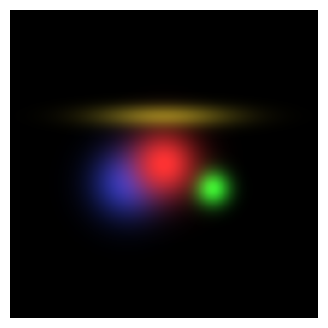

In [ ]:
import torch
import matplotlib.pyplot as plt
from gsplat import rasterization

device = "cuda"
W, H = 256, 256

# Four Gaussians: position, orientation, size, opacity, colour.
means = torch.tensor([
    [ 0.0,  0.0, 3.0],   # red, centre
    [ 0.6,  0.3, 3.0],   # green, right, same depth
    [-0.6,  0.3, 4.0],   # blue, left, further away
    [ 0.0, -0.5, 2.5],   # yellow, below, closest
], device=device)

quats = torch.tensor([[1.0, 0.0, 0.0, 0.0]], device=device).repeat(4, 1)  # no rotation

scales = torch.tensor([                     # semi-axes in world units
    [0.30, 0.30, 0.30],                     # round
    [0.15, 0.15, 0.15],                     # small
    [0.40, 0.40, 0.40],                     # large
    [0.50, 0.08, 0.10],                     # stretched along x
], device=device)

opacities = torch.tensor([1.0, 1.0, 0.8, 0.5], device=device)

colors = torch.tensor([
    [1.0, 0.2, 0.2],
    [0.2, 1.0, 0.2],
    [0.2, 0.3, 1.0],
    [1.0, 0.9, 0.2],
], device=device)

# Camera at the origin looking down +z, so viewmat is the identity.
viewmats = torch.eye(4, device=device)[None]
Ks = torch.tensor([[[200.0, 0.0, W / 2],
                    [0.0, 200.0, H / 2],
                    [0.0, 0.0, 1.0]]], device=device)

renders, alphas, info = rasterization(
    means, quats, scales, opacities, colors,
    viewmats, Ks, W, H,
    backgrounds=torch.zeros(1, 3, device=device),
)

plt.figure(figsize=(4, 4))
plt.imshow(renders[0].cpu().numpy())
plt.axis("off")
plt.show()